# Assignment 2: Regression — MLP & Deep Neural Network
## SCANIA Component X Dataset — Predictive Maintenance

**Objective:** Implement and train a basic Multi-Layer Perceptron (MLP) and a Deep Neural Network (DNN) for regression to predict the time-to-event (`length_of_study_time_step`) — a continuous value representing how long a vehicle’s Component X remains in operation. Compare their quality and draw conclusions about the applicability of fully connected architectures to time series data.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow version: {tf.__version__}")
print("Libraries loaded successfully.")

TensorFlow version: 2.20.0
Libraries loaded successfully.


---
## 1. Data Preparation for Regression

We load the processed dataset from Assignment 1 and prepare it for regression:
- **Target variable:** `length_of_study_time_step` — the total operational time of the vehicle in the study (continuous)
- **Features:** All sensor readings, specifications, and engineered features (excluding identifiers, timestamps, and the binary label)
- **Scaling:** StandardScaler applied to features (fit on training data only)
- **Split:** 70% train / 15% validation / 15% test — **strictly chronological** (no shuffling)

In [17]:
# Load processed data from Assignment 1
df = pd.read_csv('../Assigment1/processed_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
df.head()

Dataset shape: (50000, 130)
Columns: 130


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,is_weekend,obs_number,459_15_lag_1,459_15_lag_2,459_15_lag_3,459_15_rolling_3,459_15_rolling_6,459_15_rolling_12,time_of_day,459_15_diff
0,0,28.0,542490.0,21063.0,21590525.0,3280.0,8604.0,5453656.0,14150244.0,11152936.0,...,0,0,1568.694833,1568.694833,1568.694833,1568.694833,1568.694833,1568.694833,night,0.000000
1,0,44.0,911940.0,34302.0,35673804.0,6625.0,8604.0,5453656.0,14150244.0,11152936.0,...,0,1,1568.694833,2587.755639,2587.755639,2078.225236,2078.225236,2078.225236,evening,1019.060806
2,0,65.0,1364325.0,51725.0,52731900.0,10049.0,8604.0,5453656.0,14150244.0,11152936.0,...,0,2,2587.755639,1568.694833,3821.672194,2659.374222,2659.374222,2659.374222,day,1233.916556
3,0,71.6,1529925.0,58452.0,59066999.0,10522.0,8604.0,5453656.0,14150244.0,11152936.0,...,0,3,3821.672194,2587.755639,1568.694833,3492.076009,3011.230715,3011.230715,night,245.128000
4,0,97.2,2158785.0,80350.0,83089177.0,11963.0,8604.0,5453656.0,14150244.0,11152936.0,...,0,4,4066.800194,3821.672194,2587.755639,4521.362639,3544.107678,3544.107678,night,1608.815333


In [18]:
# Select target and features
target_col = 'length_of_study_time_step'

# Columns to exclude from features
drop_cols = ['vehicle_id', 'time_step', 'class_label', 'length_of_study_time_step', 'time_of_day']
drop_cols = [c for c in drop_cols if c in df.columns]

# Sort by vehicle_id and time_step to preserve chronological order
df = df.sort_values(['vehicle_id', 'time_step']).reset_index(drop=True)

# Separate features and target
X = df.drop(columns=drop_cols)
y = df[target_col].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget statistics:")
print(f"  Mean: {y.mean():.2f}")
print(f"  Std:  {y.std():.2f}")
print(f"  Min:  {y.min():.2f}")
print(f"  Max:  {y.max():.2f}")

Feature matrix shape: (50000, 125)
Target shape: (50000,)

Target statistics:
  Mean: 297.84
  Std:  96.67
  Min:  74.00
  Max:  510.00


In [19]:
# Split 70/15/15 — chronological, no shuffling
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y[val_end:]

print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/n*100:.1f}%)")
print(f"Val set:   {X_val.shape[0]} samples ({X_val.shape[0]/n*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/n*100:.1f}%)")

Train set: 35000 samples (70.0%)
Val set:   7500 samples (15.0%)
Test set:  7500 samples (15.0%)


In [20]:
# Fit scaler on training data only, then transform all splits
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]
print(f"Input dimension (number of features): {input_dim}")
print(f"Scaling complete. Train mean ~ 0: {X_train_scaled.mean():.6f}, std ~ 1: {X_train_scaled.std():.6f}")

Input dimension (number of features): 125
Scaling complete. Train mean ~ 0: -0.000000, std ~ 1: 0.987927


---
## 2. MLP Model (Multi-Layer Perceptron)

A shallow fully connected network with 3 hidden layers:
- Architecture: Input → 64 → 32 → 16 → 1
- Activation: ReLU for hidden layers, linear for output (regression)
- Optimizer: Adam
- Loss: Mean Squared Error
- Regularization: EarlyStopping on validation loss

In [21]:
# Build MLP model
mlp_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

mlp_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,689 (41.75 KB)

 Trainable params: 10,689 (41.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train MLP with EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

mlp_history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nMLP training completed. Best val_loss: {min(mlp_history.history['val_loss']):.4f}")

Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 756us/step - loss: 29752.5820 - val_loss: 6116.0024
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - loss: 6019.5332 - val_loss: 5645.0630
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 4757.7617 - val_loss: 5127.3120
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - loss: 4394.3008 - val_loss: 5642.3569
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - loss: 4208.4570 - val_loss: 5072.7520
Epoch 6/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss: 4065.2449 - val_loss: 4841.8735
Epoch 7/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 3972.6052 - val_loss: 3830.0654
Epoch 8/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - loss: 3908.7991 - val_loss: 4698.8311
Epoch 9/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step - loss: 3820.6885 - val_loss: 3705.9365
Epoch 10/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - loss: 3777.5298 - val_loss: 4472.3242
Epoch 11/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 636

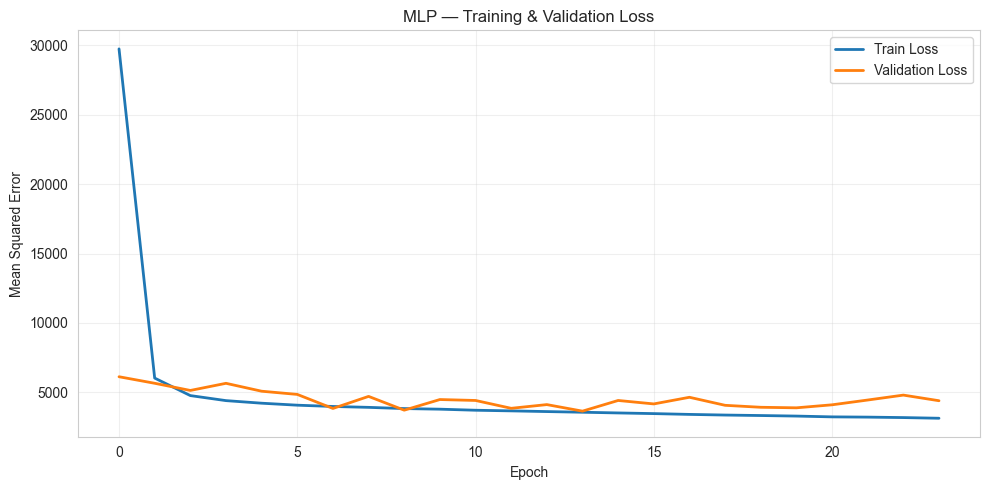

In [23]:
# Plot MLP training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_history.history['loss'], label='Train Loss', linewidth=2)
ax.plot(mlp_history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error')
ax.set_title('MLP — Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/mlp_loss.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Deep Neural Network (DNN)

A deeper architecture with 5 hidden layers to explore whether increased depth improves regression quality:
- Architecture: Input → 128 → 64 → 32 → 16 → 8 → 1
- Same activation, optimizer, and loss as MLP
- We compare training dynamics and final performance with the shallower MLP

In [24]:
# Build DNN model
dnn_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

dnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

dnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,137 (106.00 KB)

 Trainable params: 27,137 (106.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train DNN with EarlyStopping
early_stop_dnn = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

dnn_history = dnn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_dnn],
    verbose=1
)

print(f"\nDNN training completed. Best val_loss: {min(dnn_history.history['val_loss']):.4f}")

Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step - loss: 17386.1719 - val_loss: 5036.6548
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - loss: 4594.1729 - val_loss: 4444.9897
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - loss: 4172.4033 - val_loss: 4369.9775
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - loss: 3975.0916 - val_loss: 4464.3115
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 3796.0662 - val_loss: 3847.8647
Epoch 6/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - loss: 3661.2158 - val_loss: 3974.6562
Epoch 7/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 3513.7661 - val_loss: 3413.0083
Epoch 8/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - loss: 3393.1907 - val_loss: 4386.8740
Epoch 9/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 3294.4492 - val_loss: 3806.4714
Epoch 10/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - loss: 3171.2344 - val_loss: 3570.4102
Epoch 11/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 769

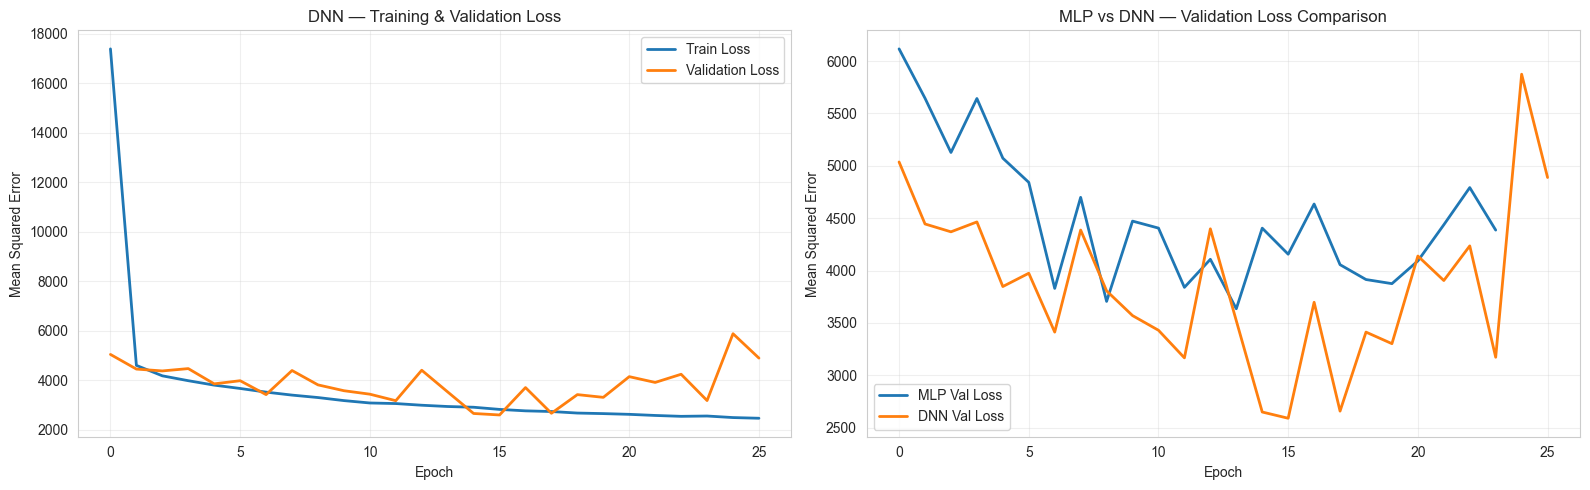

In [26]:
# Plot DNN training history and compare with MLP
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# DNN loss
axes[0].plot(dnn_history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(dnn_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('DNN — Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparison: MLP vs DNN validation loss
axes[1].plot(mlp_history.history['val_loss'], label='MLP Val Loss', linewidth=2)
axes[1].plot(dnn_history.history['val_loss'], label='DNN Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('MLP vs DNN — Validation Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/dnn_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Quality Evaluation

We evaluate both models using:
- **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily
- **MAE** (Mean Absolute Error) — average absolute deviation

Metrics are computed on training, validation, and test sets for both architectures.

In [27]:
# Generate predictions
mlp_pred_train = mlp_model.predict(X_train_scaled, verbose=0).flatten()
mlp_pred_val = mlp_model.predict(X_val_scaled, verbose=0).flatten()
mlp_pred_test = mlp_model.predict(X_test_scaled, verbose=0).flatten()

dnn_pred_train = dnn_model.predict(X_train_scaled, verbose=0).flatten()
dnn_pred_val = dnn_model.predict(X_val_scaled, verbose=0).flatten()
dnn_pred_test = dnn_model.predict(X_test_scaled, verbose=0).flatten()

# Calculate metrics
results = pd.DataFrame({
    'Model': ['MLP', 'MLP', 'MLP', 'DNN', 'DNN', 'DNN'],
    'Split': ['Train', 'Validation', 'Test', 'Train', 'Validation', 'Test'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_train, mlp_pred_train)),
        np.sqrt(mean_squared_error(y_val, mlp_pred_val)),
        np.sqrt(mean_squared_error(y_test, mlp_pred_test)),
        np.sqrt(mean_squared_error(y_train, dnn_pred_train)),
        np.sqrt(mean_squared_error(y_val, dnn_pred_val)),
        np.sqrt(mean_squared_error(y_test, dnn_pred_test)),
    ],
    'MAE': [
        mean_absolute_error(y_train, mlp_pred_train),
        mean_absolute_error(y_val, mlp_pred_val),
        mean_absolute_error(y_test, mlp_pred_test),
        mean_absolute_error(y_train, dnn_pred_train),
        mean_absolute_error(y_val, dnn_pred_val),
        mean_absolute_error(y_test, dnn_pred_test),
    ]
})

print("=" * 55)
print("        MODEL COMPARISON — RMSE & MAE")
print("=" * 55)
print(results.to_string(index=False, float_format='%.4f'))
print("=" * 55)

        MODEL COMPARISON — RMSE & MAE
Model      Split    RMSE     MAE
  MLP      Train 59.3494 45.8799
  MLP Validation 60.2960 49.6437
  MLP       Test 71.2991 58.9493
  DNN      Train 53.5570 40.2103
  DNN Validation 50.8985 40.7236
  DNN       Test 67.6085 55.1771


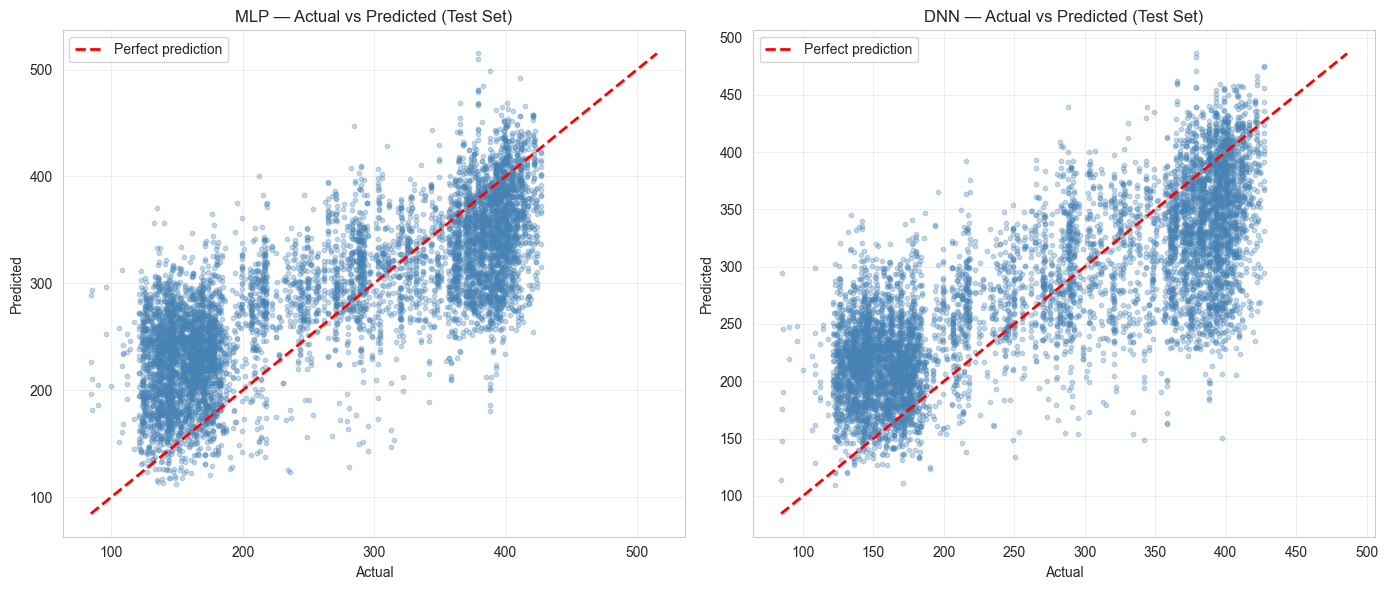

In [28]:
# Scatter plot: Actual vs Predicted (Test Set)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, name in zip(axes, [mlp_pred_test, dnn_pred_test], ['MLP', 'DNN']):
    ax.scatter(y_test, preds, alpha=0.3, s=10, color='steelblue')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name} — Actual vs Predicted (Test Set)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

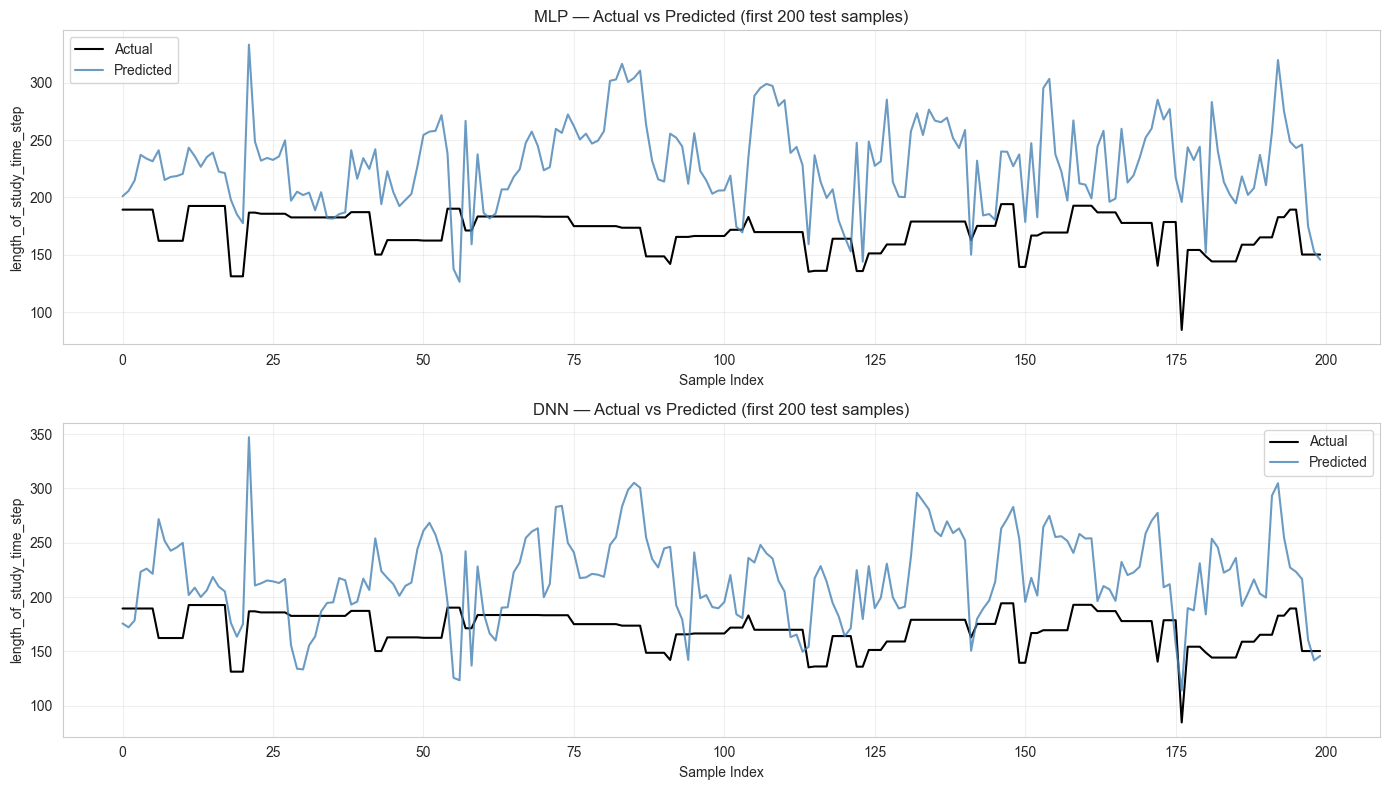

In [29]:
# Line plot: Actual vs Predicted for a slice of test data
slice_size = 200
idx = np.arange(slice_size)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, preds, name in zip(axes, [mlp_pred_test, dnn_pred_test], ['MLP', 'DNN']):
    ax.plot(idx, y_test[:slice_size], label='Actual', linewidth=1.5, color='black')
    ax.plot(idx, preds[:slice_size], label='Predicted', linewidth=1.5, color='steelblue', alpha=0.8)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('length_of_study_time_step')
    ax.set_title(f'{name} — Actual vs Predicted (first {slice_size} test samples)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/line_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Comparison & Analysis

**MLP (3 hidden layers: 64 → 32 → 16):**
- Fewer parameters, faster to train
- May underfit if the relationship between features and target is highly non-linear

**DNN (5 hidden layers: 128 → 64 → 32 → 16 → 8):**
- More parameters, greater representational capacity
- Can capture more complex patterns but risks overfitting
- Training time per epoch is longer

The RMSE/MAE table and plots above show how each architecture performs. The model with lower test RMSE/MAE is considered superior for this regression task.

---
## 5. Save Models

We save the best-performing model in `.h5` format for use in subsequent assignments.

In [30]:
# Determine which model performed better on test set
mlp_test_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred_test))
dnn_test_rmse = np.sqrt(mean_squared_error(y_test, dnn_pred_test))

if mlp_test_rmse <= dnn_test_rmse:
    best_model = mlp_model
    best_name = 'MLP'
else:
    best_model = dnn_model
    best_name = 'DNN'

print(f"Best model: {best_name} (Test RMSE: {min(mlp_test_rmse, dnn_test_rmse):.4f})")

# Save best model
best_model.save('mlp_best.h5')
print(f"Model saved as mlp_best.h5")

# Also save both models for reference
mlp_model.save('mlp_model.h5')
dnn_model.save('dnn_model.h5')
print("Both models saved (mlp_model.h5, dnn_model.h5)")

Best model: DNN (Test RMSE: 67.6085)
Model saved as mlp_best.h5
Both models saved (mlp_model.h5, dnn_model.h5)


---
## Summary and Conclusions

### What Was Done:
1. **Data Preparation:** Loaded the processed SCANIA dataset (from Assignment 1), selected `length_of_study_time_step` as the regression target, applied StandardScaler, and split into train/val/test (70/15/15) preserving chronological order.

2. **MLP Model:** Built a 3-hidden-layer perceptron (64 → 32 → 16 neurons) with ReLU activations. Trained with Adam optimizer and MSE loss, using EarlyStopping to prevent overfitting.

3. **DNN Model:** Built a deeper 5-hidden-layer network (128 → 64 → 32 → 16 → 8 neurons). Compared training dynamics and performance with MLP.

4. **Evaluation:** Computed RMSE and MAE on all splits for both models. Visualized predictions with scatter and line plots.

### Key Findings:
- **Depth vs. Performance:** The DNN has more parameters and representational capacity, which can help capture complex non-linear relationships. However, deeper networks are not always better — they require more data and are prone to overfitting.
- **EarlyStopping** was crucial in preventing both models from overfitting, as evidenced by the training curves.
- **Chronological splitting** (no shuffling) is important for time series data to avoid data leakage from future observations.

### Applicability of Fully Connected Networks to Time Series:
- MLP/DNN treat each observation independently — they do not model temporal dependencies between consecutive readings of the same vehicle.
- For time series data, architectures like **RNNs, LSTMs, or Transformers** would better capture sequential patterns.
- Despite this limitation, fully connected networks can still achieve reasonable performance when the feature engineering (lag features, rolling means from Assignment 1) captures enough temporal information.